# Analysis

## Part 1. The whole dataset

In [1]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("data/vk_photos_perm_enriched.csv")
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows from {DATA_PATH}, columns: {', '.join(df.columns)}")
df.head(3)

Loaded 5,805 rows from data/vk_photos_perm_enriched.csv, columns: photo_id, owner_id, album_id, post_id, post_url, image_url, related_photo_urls, hashtags, date_human, lat, long, poi_lat, poi_lon, distance_meters, poi_name, user_id, user_gender, user_age, user_city, user_city_id, user_kind, post_text, inside_poi_area, inside_poi_building, annotation_text_description, annotation_location_type, annotation_photo_type, annotation_is_advertisement, annotation_city_objects, annotation_city_activities, annotation_user_intent, annotation_has_building, annotation_has_synagogue, annotation_has_feor, annotation_has_other_building, annotation_confidence, model_version, model_timestamp


,photo_id,owner_id,album_id,post_id,post_url,image_url,related_photo_urls,hashtags,date_human,lat,...,annotation_city_objects,annotation_city_activities,annotation_user_intent,annotation_has_building,annotation_has_synagogue,annotation_has_feor,annotation_has_other_building,annotation_confidence,model_version,model_timestamp
0,423419286,354796984,-7,NaN,NaN,https://sun9-7.userapi.com/s/v1/ig1/dIvBBkO2jP...,NaN,NaN,2016-07-15 07:49:46,58.007828,...,NaN,NaN,показать товар,False,False,False,False,0.78,gpt-5-nano,2025-11-23T17:12:55.794549+00:00
1,457250512,-170690865,-7,NaN,NaN,https://sun9-63.userapi.com/s/v1/ig2/g8wyS2B9X...,NaN,NaN,2022-05-31 12:34:15,58.007806,...,"человек, стул, дверь, стена, пол",позирует перед камерой,показать одежду,False,False,False,False,0.78,gpt-5-nano,2025-11-23T17:12:55.794589+00:00
2,403011859,261660768,-7,5179.0,https://vk.com/wall261660768_5179,https://sun9-10.userapi.com/s/v1/ig1/iHPfVE7OC...,NaN,NaN,2016-02-26 13:41:06,58.007905,...,"зеркало, витрины, пол, стойки одежды, куртки, ...","примерка, покупки",показать пальто,False,False,False,False,0.82,gpt-5-nano,2025-11-23T17:12:55.794616+00:00


In [2]:
total = len(df)
print(f"Total rows: {total}")

Total rows: 5805


In [3]:
! pip install matplotlib seaborn


[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_poi_year_counts(df, name="Total photos"):
    poi_year_counts = df.groupby(["poi_name", "year"]).size().reset_index(name="count")
    plt.figure(figsize=(8, 4))
    sns.barplot(x="year", y="count", hue="poi_name", data=poi_year_counts)
    plt.title(f"{name} by POI name and year")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.legend(title="POI Name")

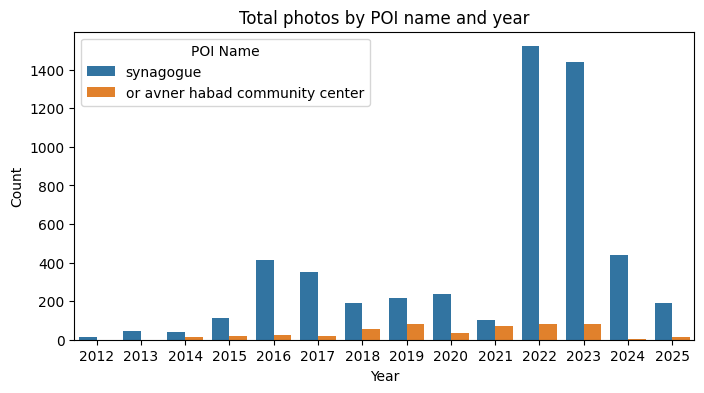

In [8]:
# Photos by POI name and year
df["date"] = pd.to_datetime(df["date_human"])
df["year"] = df["date"].dt.year
df["poi_name"] = df["poi_name"].fillna("unknown")

visualize_poi_year_counts(df)

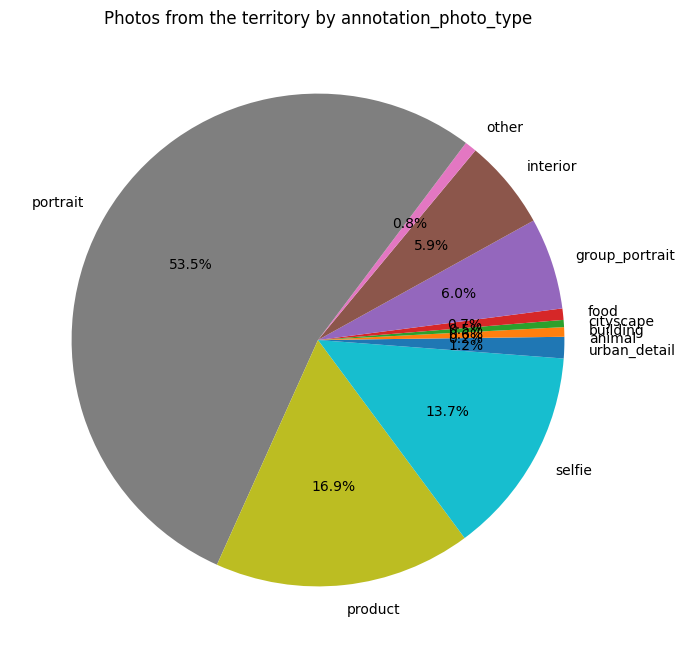

In [14]:
def visualize_photo_types(df, name="Photos from the territory"):
    grouped = df.groupby(["annotation_photo_type"]).size().reset_index(name="count")
    # a pie chart with annotation_photo_type count
    plt.figure(figsize=(8, 8))
    plt.pie(grouped["count"], labels=grouped["annotation_photo_type"], autopct="%1.1f%%")
    plt.title(f"{name} by annotation_photo_type")
    plt.show()

visualize_photo_types(df)


In [ ]:
def visualize_commercial_photos_by_poi(df, name="Ph"):

### Part 1.1
Photos from the buildings territories. 

In [93]:
inside_building_mask = df["inside_poi_building"].fillna(False)
inside_df = df[inside_building_mask]
print(f"Photos from the buildings territories: {len(inside_df):,}")

Photos from the buildings territories: 375


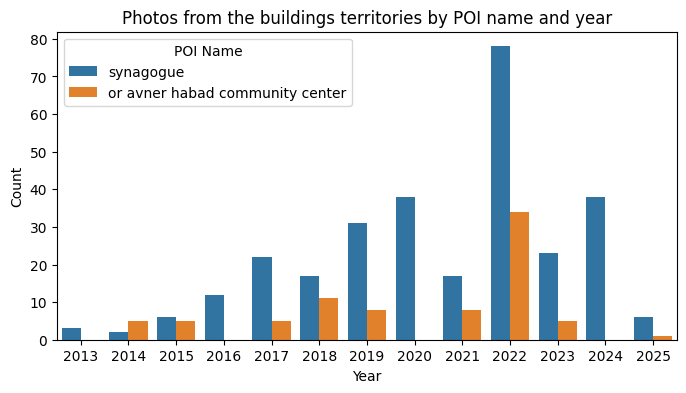

In [94]:
### Photos from the building 
visualize_poi_year_counts(inside_df, name="Photos from the buildings territories")

In [129]:
def visualize_poi_location_type(df, name="Photos from the territory"):
    grouped = df.groupby(["poi_name", "annotation_location_type"]).size().reset_index(name="count")
    grouped["share"] = grouped["count"] / grouped.groupby("poi_name")["count"].transform("sum") * 100
    # make two pie charts, one for each poi_name
    plt.figure(figsize=(8, 4))
    for i, poi_name in enumerate(grouped["poi_name"].unique()):
        poi_data = grouped[grouped["poi_name"] == poi_name]
        plt.subplot(1, 2, i + 1)
        plt.pie(poi_data["count"], labels=poi_data["annotation_location_type"], autopct="%1.1f%%")
        plt.title(f"{name} of {poi_name} by location type")
        plt.show()


/var/folders/yz/1n0b98zd7zqcxhyl8wl435h40000gn/T/ipykernel_51204/3962888877.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inside_df["annotation_location_type"] = inside_df["annotation_location_type"].fillna("unknown")


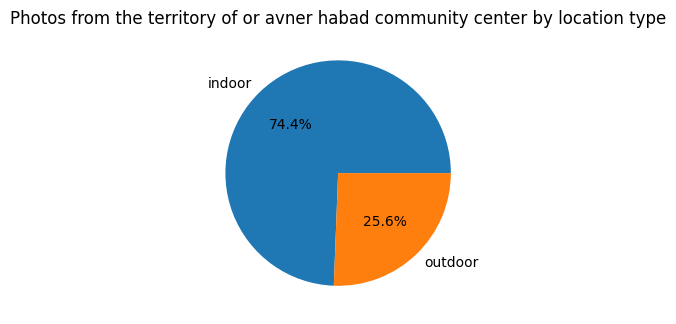

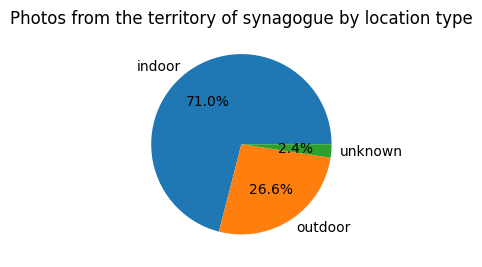

In [130]:
# Photos from the buildings territories by poi and annotation_location_type, share of the total by poi
inside_df["annotation_location_type"] = inside_df["annotation_location_type"].fillna("unknown") 
visualize_poi_location_type(inside_df)

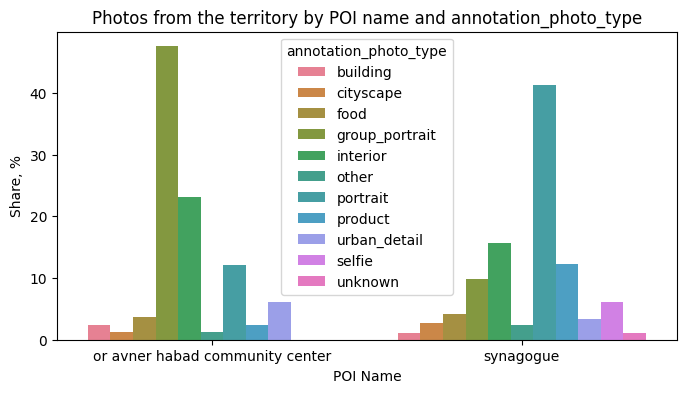

In [137]:
def visualize_poi_photo_type(df, name="Photos from the territory"):
    grouped = df.groupby(["poi_name", "annotation_photo_type"]).size().reset_index(name="count")
    grouped["share"] = grouped["count"] / grouped.groupby("poi_name")["count"].transform("sum") * 100
    # a bar chart with share of the total by poi_name for each annotation_photo_type
    plt.figure(figsize=(8, 4))
    sns.barplot(x="poi_name", y="share", hue="annotation_photo_type", data=grouped)
    plt.title(f"{name} by POI name and annotation_photo_type")
    plt.xlabel("POI Name")
    plt.ylabel("Share, %")
    plt.show()

visualize_poi_photo_type(inside_df)


### Part 1.2
Photos from areas of visibility with building in it

In [ ]:
building_mask = df["annotation_has_building"].fillna(False) & (~df["inside_poi_building"].fillna(False))
buildings_df = df[building_mask]

print(f"Photos from areas of visibility with building in them: {len(buildings_df):,}")

Photos from areas of visibility with building in it: 841


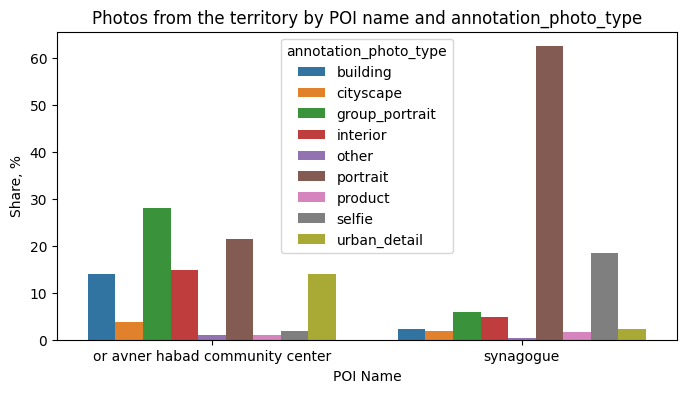

In [139]:
visualize_poi_photo_type(buildings_df)

## Part 2. 
Trying to clusterize photographs

In [ ]:
! pip install sklearn

In [ ]:
cluster_df = df.copy()

In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# convert text to TF–IDF vectors
vectorizer = TfidfVectorizer(
    stop_words="russian",
    min_df=2,                # tweak for your data size
    max_features=5000        # guard against sparse noise
)
tfidf = vectorizer.fit_transform(cluster_df["annotation_text_description"])

k = 10
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
cluster_df["cluster"] = kmeans.fit_predict(tfidf)

print(cluster_df[["photo_id", "cluster", "annotation_text_description"]])